# 04 - Clusterização de Voos

Agrupamento para entender perfis operacionais sem usar o alvo.

In [ ]:
# Imports e leitura da amostra processada
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("seaborn-v0_8")
data = pd.read_parquet("../data/processed/flights_sample.parquet")
features = ["MONTH","DAY_OF_WEEK","DEP_HOUR","DISTANCE"]
X = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X.shape


(300000, 4)

## 1. Método do cotovelo (leve)

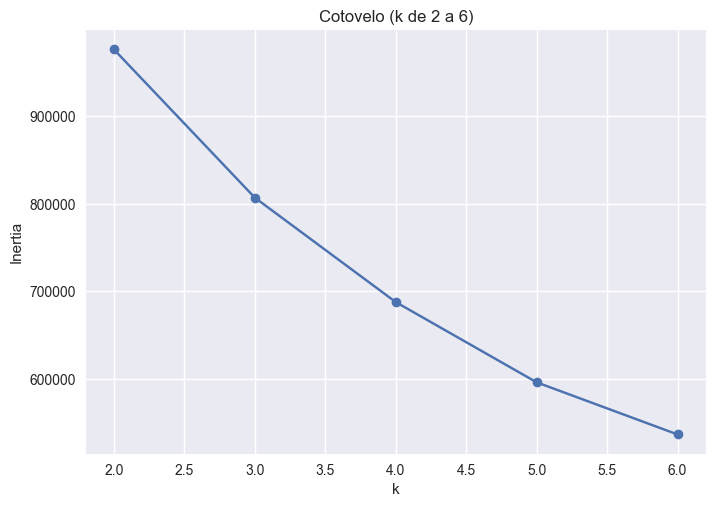

In [5]:
# Metodo do cotovelo: calcula inercia para diferentes k
inertia = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.plot(range(2,7), inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Cotovelo (k de 2 a 6)")
plt.show()

## 2. Ajuste final (k=4)

            MONTH  DAY_OF_WEEK   DEP_HOUR     DISTANCE   DELAYED
CLUSTER                                                         
0        3.345267     2.767031  13.005344   630.377108  0.199002
1        6.723568     4.065823  13.118384  2032.498415  0.180819
2        9.678991     2.694887  13.163059   627.002649  0.167999
3        6.599287     6.163363  12.867101   635.866132  0.165926


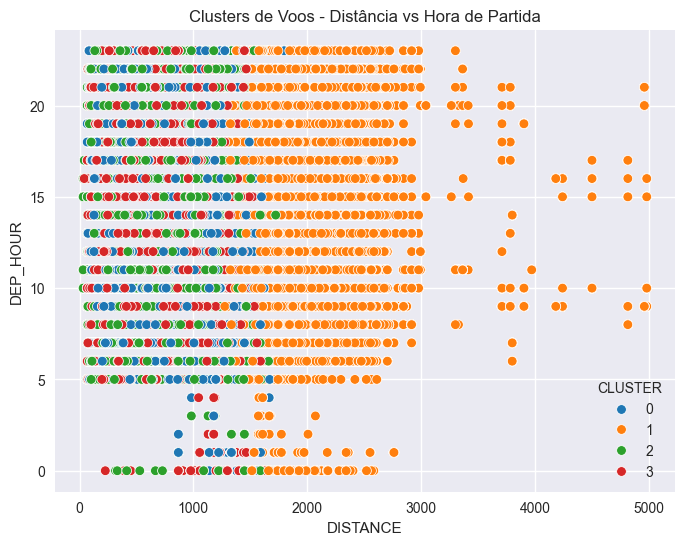

In [ ]:
# Ajusta K-Means final com k=4 e anexa clusters aos dados
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
data["CLUSTER"] = clusters

perfil = data.groupby("CLUSTER")[features + ["DELAYED"]].agg({
    "MONTH":"mean",
    "DAY_OF_WEEK":"mean",
    "DEP_HOUR":"mean",
    "DISTANCE":"mean",
    "DELAYED":"mean"
})
print(perfil)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x="DISTANCE",
    y="DEP_HOUR",
    hue="CLUSTER",
    palette="tab10"
)

plt.title("Clusters de Voos - Distância vs Hora de Partida")
plt.show()

sns.pairplot(
    data=data,
    vars=features,
    hue="CLUSTER",
    palette="tab10"
)
plt.show()

perfil_plot = perfil.reset_index()

perfil_plot_melt = perfil_plot.melt(
    id_vars="CLUSTER",
    value_vars=features + ["DELAYED"],
    var_name="FEATURE",
    value_name="VALUE"
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=perfil_plot_melt,
    x="FEATURE",
    y="VALUE",
    hue="CLUSTER",
    marker="o"
)

plt.title("Perfil médio dos clusters")
plt.show()

## 3. Taxa de atraso por cluster

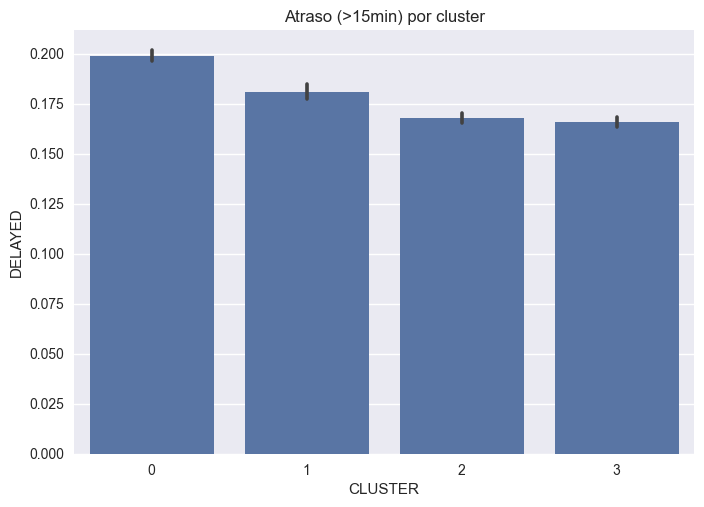

In [7]:
# Visualiza taxa media de atraso por cluster
sns.barplot(data=data, x="CLUSTER", y="DELAYED")
plt.title("Atraso (>15min) por cluster")
plt.show()

### Leituras
- Clusters distinguem horários médios e distâncias.
- Taxas de atraso variam entre grupos, sugerindo perfis operacionais com maior risco mesmo sem usar a variável alvo.